# Eksperimen #2 — mean+std pooling (2048-d)

**Perubahan tunggal** dari eksperimen esf1: fitur input berpindah dari embedding
mean-pool (1024-d, `yamnet_{ds}.npz`) → **mean+std** (2048-d, `yamnet_stats_{ds}.npz`).
Semua yang lain identik: split, seed, arsitektur head MLP 256→128, dan recipe
early-stopping pada val macro-F1. A/B bersih.

**Hipotesis:** std antar-frame menangkap modulasi temporal (wailing) yang membedakan
sirine, sehingga menaikkan diskriminasi ambulance/firetruck/police di D2.

**Pembanding:** D1 esf1 `0.9643` · D2 esf1 `0.7725` (D2 baseline `0.7639`).

In [1]:
import json
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ML_DIR = ROOT / "ml"
CACHE_TAG = "yamnet_stats"                              # <- fitur mean+std


def load_dataset(dataset: str, cache_tag: str = CACHE_TAG):
    """Rakit X/y train-val-test dari cache + split, standardisasi (statistik train)."""
    data = np.load(ML_DIR / "cache" / f"{cache_tag}_{dataset}.npz", allow_pickle=True)
    emb_by_file = {fn: e for fn, e in zip(data["filename"], data["emb"])}
    classes = sorted(set(data["label"]))
    idx = {c: i for i, c in enumerate(classes)}

    def split(name):
        df = pd.read_csv(ML_DIR / f"split_{dataset}_{name}.csv")
        X = np.stack([emb_by_file[fn] for fn in df.filename]).astype(np.float32)
        y = df.label.map(idx).to_numpy()
        return X, y

    Xtr, ytr = split("train"); Xva, yva = split("val"); Xte, yte = split("test")
    mean = Xtr.mean(0, keepdims=True); std = Xtr.std(0, keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)               # kolom near-konstan tak diskalakan
    Xtr = (Xtr - mean) / std; Xva = (Xva - mean) / std; Xte = (Xte - mean) / std
    return classes, (Xtr, ytr), (Xva, yva), (Xte, yte)


for ds in ("d1", "d2"):
    classes, (Xtr, *_), *_ = load_dataset(ds)
    print(f"{ds}: {classes} · fitur dim = {Xtr.shape[1]}")

d1: ['ambulance', 'firetruck', 'traffic'] · fitur dim = 2048
d2: ['ambulance', 'firetruck', 'police', 'traffic'] · fitur dim = 2048


## Callback val macro-F1 + head (identik dengan esf1)

In [2]:
class ValMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__(); self.X_val, self.y_val = X_val, y_val
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_pred = self.model.predict(self.X_val, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, y_pred, average="macro")


def build_head(input_dim, n_classes):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

## Jalankan D1 & D2

In [3]:
def run_experiment(dataset: str):
    tf.keras.utils.set_random_seed(SEED)
    classes, (Xtr, ytr), (Xva, yva), (Xte, yte) = load_dataset(dataset)

    model = build_head(Xtr.shape[1], len(classes))
    callbacks = [
        ValMacroF1(Xva, yva),
        tf.keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max",
                                         patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max",
                                             factor=0.5, patience=8, min_lr=1e-5),
    ]
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva),
                     epochs=200, batch_size=32, callbacks=callbacks, verbose=0)
    best_epoch = int(np.argmax(hist.history["val_macro_f1"])) + 1

    y_pred = model.predict(Xte, verbose=0).argmax(axis=1)
    macro_f1 = f1_score(yte, y_pred, average="macro")
    acc = accuracy_score(yte, y_pred)

    exp_id = f"{dataset}_yamnet_mlp_meanstd"
    art = ML_DIR / "artifacts" / exp_id; art.mkdir(parents=True, exist_ok=True)
    model.save(art / "model.keras")
    (art / "metrics.json").write_text(json.dumps({
        "test_macro_f1": float(macro_f1), "test_accuracy": float(acc),
        "per_class_f1": dict(zip(classes, f1_score(yte, y_pred, average=None).tolist())),
        "best_epoch": best_epoch, "feature": "yamnet_meanstd_2048",
    }, indent=2))
    pd.DataFrame([{
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "exp_id": exp_id, "dataset": dataset, "backbone": "yamnet",
        "head": "mlp_256_128_meanstd", "n_train": len(ytr), "n_test": len(yte),
        "best_epoch": best_epoch, "test_macro_f1": round(macro_f1, 4),
        "test_accuracy": round(acc, 4),
    }]).to_csv(ML_DIR / "experiments.csv", mode="a", header=False, index=False)

    print(f"[{dataset}] best_epoch={best_epoch} · TEST macro-F1={macro_f1:.4f} · acc={acc:.4f}")
    print(classification_report(yte, y_pred, target_names=classes, digits=3))
    return {"dataset": dataset, "classes": classes, "macro_f1": macro_f1,
            "y_test": yte, "y_pred": y_pred}


results = {r["dataset"]: r for r in (run_experiment(ds) for ds in ("d1", "d2"))}

[d1] best_epoch=3 · TEST macro-F1=0.9762 · acc=0.9765
              precision    recall  f1-score   support

   ambulance      0.964     0.964     0.964        28
   firetruck      0.964     0.964     0.964        28
     traffic      1.000     1.000     1.000        29

    accuracy                          0.976        85
   macro avg      0.976     0.976     0.976        85
weighted avg      0.976     0.976     0.976        85



[d2] best_epoch=12 · TEST macro-F1=0.7983 · acc=0.8000
              precision    recall  f1-score   support

   ambulance      0.745     0.655     0.697        58
   firetruck      0.778     0.750     0.764        56
      police      0.716     0.803     0.757        66
     traffic      0.967     0.983     0.975        60

    accuracy                          0.800       240
   macro avg      0.802     0.798     0.798       240
weighted avg      0.800     0.800     0.799       240



## Confusion matrix D2 — apakah kebingungan sirine berkurang?

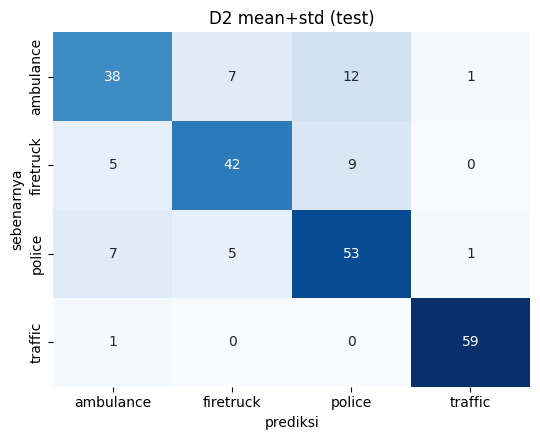

In [4]:
r = results["d2"]
cm = confusion_matrix(r["y_test"], r["y_pred"])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=r["classes"], yticklabels=r["classes"], cbar=False)
plt.xlabel("prediksi"); plt.ylabel("sebenarnya")
plt.title("D2 mean+std (test)")
plt.tight_layout()
fig_dir = ROOT / "figures" / "train_d2"; fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "confusion_matrix_meanstd.png", bbox_inches="tight")
plt.show()

## Perbandingan lintas eksperimen

In [5]:
baseline = {"d1": {"baseline": 0.9643, "esf1": 0.9643},
            "d2": {"baseline": 0.7639, "esf1": 0.7725}}
print(f"{'dataset':8s} {'baseline':>9s} {'esf1':>9s} {'meanstd':>9s} {'Δ vs esf1':>10s}")
for ds in ("d1", "d2"):
    new = results[ds]["macro_f1"]; b = baseline[ds]
    print(f"{ds:8s} {b['baseline']:>9.4f} {b['esf1']:>9.4f} {new:>9.4f} "
          f"{new - b['esf1']:>+10.4f}")

print("\n--- experiments.csv ---")
print(pd.read_csv(ML_DIR / "experiments.csv").to_string(index=False))

dataset   baseline      esf1   meanstd  Δ vs esf1
d1          0.9643    0.9643    0.9762    +0.0119
d2          0.7639    0.7725    0.7983    +0.0258

--- experiments.csv ---
          timestamp                exp_id dataset backbone                head  n_train  n_test  best_epoch  test_macro_f1  test_accuracy
2026-07-24T19:27:16         d1_yamnet_mlp      d1   yamnet         mlp_256_128      426      85          15         0.9643         0.9647
2026-07-24T19:27:50         d2_yamnet_mlp      d2   yamnet         mlp_256_128     1195     240           1         0.7639         0.7667
2026-07-24T19:54:56    d1_yamnet_mlp_esf1      d1   yamnet    mlp_256_128_esf1      426      85           6         0.9643         0.9647
2026-07-24T19:55:04    d2_yamnet_mlp_esf1      d2   yamnet    mlp_256_128_esf1     1195     240           8         0.7725         0.7750
2026-07-24T20:31:14 d1_yamnet_mlp_meanstd      d1   yamnet mlp_256_128_meanstd      426      85           3         0.9762         0.97

---

**Interpretasi:** kalau F1 sirine D2 naik dan confusion antar-sirine berkurang, informasi
temporal (std) memang membantu diskriminasi. Kalau nyaris tak berubah, variasi temporal
bukan bottleneck-nya → langkah berikut augmentasi atau fine-tune. (Lihat decision gate di
plan.)